In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import lmfit as lmf
from scipy.special import erfc
from scipy import interpolate
from scipy.special import spence
# from scipy.misc import derivative

photon waveform

In [2]:
time = np.linspace(0, 1000, 1000)
const = 4e-3 * 2 * np.pi

def sech_0(time, const):
    return (const/2)**0.5/np.cosh(const*(time-500))

def sech_1(time, const):
    return (6*const**3/(np.pi**2))**0.5/np.cosh(const*(time-500))*(time-500)

def sech_2(time, const):
    return (45*(2*const)**5/64/(np.pi**4))**0.5/np.cosh(const*(time-500))*((time-500)**2-(np.pi/2/const)**2/3)

def sech_3(time, const):
    return (175*(2*const)**7)**0.5/24/(np.pi**3)/np.cosh(const*(time-500))*((time-500)**3-(7*(time-500)*(np.pi/(2*const))**2/5))

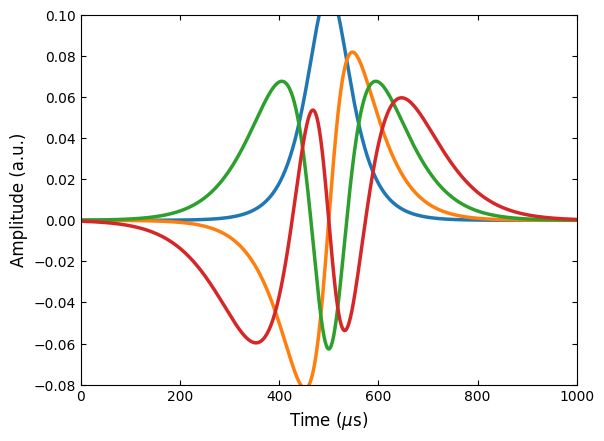

In [3]:
plt.plot(time, sech_0(time, const), label=r"$\xi_0(t)$", linewidth=2.5)
plt.plot(time, sech_1(time, const), label=r"$\xi_1(t)$", linewidth=2.5)
plt.plot(time, sech_2(time, const), label=r"$\xi_2(t)$", linewidth=2.5)
plt.plot(time, sech_3(time, const), label=r"$\xi_3(t)$", linewidth=2.5)
# plt.plot(time, sech_3(time, const), label=r"$\xi_3(t)$", linewidth=2.5)
plt.xlabel(r"Time ($\mu$s)", size='large')
plt.ylabel("Amplitude (a.u.)", size='large')
plt.xlim(0, 1000)
plt.ylim(-0.08, 0.1)
plt.tick_params(axis="x", direction="in")
plt.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.savefig("time")
# plt.legend()

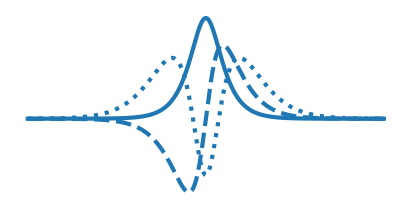

In [4]:
fig, ax = plt.subplots(1,1,figsize=(4,2),constrained_layout=True)
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True 
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

ax.plot(time+500, 10*sech_0(time, const), linestyle='-', label=r"$m=0$", color="tab:blue", linewidth=3)
ax.plot(time+500, 10*sech_1(time, const), linestyle='--', label=r"$m=1$", color="tab:blue", linewidth=3)
ax.plot(time+500, 10*sech_2(time, const), linestyle=':', label=r"$m=2$", color="tab:blue", linewidth=3)
# ax.plot(time+500, 10*sech_3(time, const), linestyle='-.', label=r"$m=3$", color="tab:blue", linewidth=3)
plt.axis('off')  # 軸を非表示に
plt.gca().set_facecolor('white')  # 背景を白に（背景が透明にされる）

# ax.plot(time+500, 10*sech_3(time, const), linestyle=':', label=r"$m=3$", color="tab:blue", linewidth=3)
# plt.legend(loc='upper left', ncol=2, fontsize=16)
# plt.savefig("target_shape_m")
plt.savefig('temporal_mode_t.png', bbox_inches='tight', transparent=True)


c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


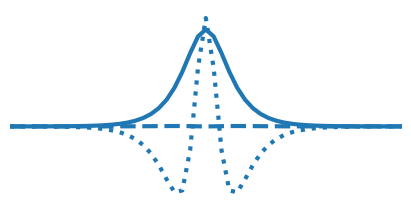

In [5]:
fig, ax = plt.subplots(1,1,figsize=(4,2),constrained_layout=True)

# --- Fourier transform helper ---
def FT(x, t):
    dt = t[1] - t[0]
    X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
    freq = np.fft.fftshift(np.fft.fftfreq(len(t), dt))
    return freq, X

# Time-domain functions
time = np.linspace(0, 1000, 2000)
y0 = 10 * sech_0(time, const)
y1 = 10 * sech_1(time, const)
y2 = 10 * sech_2(time, const)


ts = time + 500

freq0, Y0 = FT(y0, time)
freq1, Y1 = FT(y1, time)
freq2, Y2 = FT(y2, time)

ax.plot(freq0, Y0, linestyle='-',  label=r"$m=0$", color="tab:blue", linewidth=3)
ax.plot(freq1, Y1, linestyle='--', label=r"$m=1$", color="tab:blue", linewidth=3)
ax.plot(freq2, Y2, linestyle=':', label=r"$m=2$", color="tab:blue", linewidth=3)
ax.set_xlim(-freq0[-1]/40, freq0[-1]/40)
ax.axis("off")
plt.savefig('temporal_mode_f.png', bbox_inches='tight', transparent=True)
plt.show()


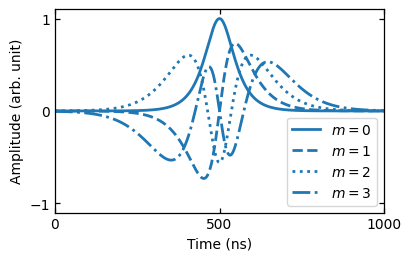

In [9]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5),constrained_layout=True)

plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 10 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True 
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

norm = np.max(sech_0(time, const))
ax.plot(time, sech_0(time, const)/norm, linestyle='-', label=r"$m=0$", color="tab:blue", linewidth=2)
ax.plot(time, sech_1(time, const)/norm, linestyle='--', label=r"$m=1$", color="tab:blue", linewidth=2)
ax.plot(time, sech_2(time, const)/norm, linestyle=':', label=r"$m=2$", color="tab:blue", linewidth=2)
ax.plot(time, sech_3(time, const)/norm, linestyle='-.', label=r"$m=3$", color="tab:blue", linewidth=2)
# plt.axis('off')  # 軸を非表示に
# plt.gca().set_facecolor('white')  # 背景を白に（背景が透明にされる）
ax.set_xticks([0, 500, 1000])
ax.set_yticks([-1, 0, 1])
plt.legend(loc='lower right', ncol=1)
plt.savefig("target_shape_m")
plt.xlabel("Time (ns)")
plt.ylim(-1.1, 1.1)
plt.xlim(0, 1000)
plt.ylabel("Amplitude (arb. unit)")
plt.savefig('temporal_mode_t1.png', bbox_inches='tight', transparent=True)


In [4]:
def fourier_tr_padding_odd(x, y, n_padding=100):
    N = len(y)
    # y_n = y - np.mean(y)

    zeros = np.zeros(N*(n_padding-1)//2)
    y_pad = np.concatenate([zeros, y, zeros])

    data_fft = np.fft.fft(y_pad)
    freq_fft = np.fft.fftfreq(len(y_pad), x[1]-x[0])

    data_fft = np.fft.fftshift(data_fft)
    freq_fft = np.fft.fftshift(freq_fft)

    return freq_fft, data_fft


In [5]:
import scipy.signal as sg
def fourier_tr_padding(x, y):
    N = len(x)
    offset_init = np.mean(y)
    y_n = y - offset_init
    n_padding = 100
    freq_fft = np.fft.fftfreq(N*n_padding, (x[1]-x[0]))
    data_fft = np.fft.fft(np.concatenate([y_n, [0]*N*(n_padding-1)]))
    sorted_idx = np.argsort(freq_fft)
    freq_fft = freq_fft[sorted_idx]
    data_fft = data_fft[sorted_idx]
    return freq_fft, data_fft

def start_stop(x, y, xstart, xstop):
    x_list = np.array([el for el in x if el>=xstart and el<=xstop])
    x_idx = [i for i, el in enumerate(x) if el>=xstart and el<=xstop]
    y_list = y[x_idx]
    return x_list, y_list

def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y

def demodulate(t, data, demodulation_if = 0.125):
    return (data * np.exp(2j * np.pi * demodulation_if * t)).mean(axis=-1)

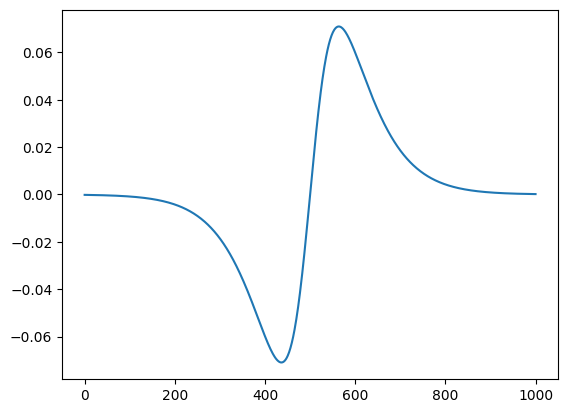

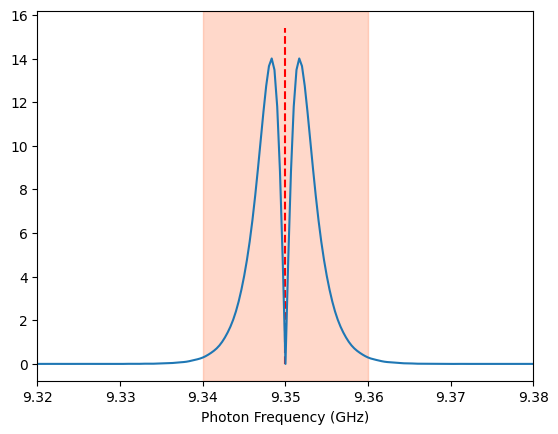

Text(0.5, 0, 'Photon Frequency (GHz)')

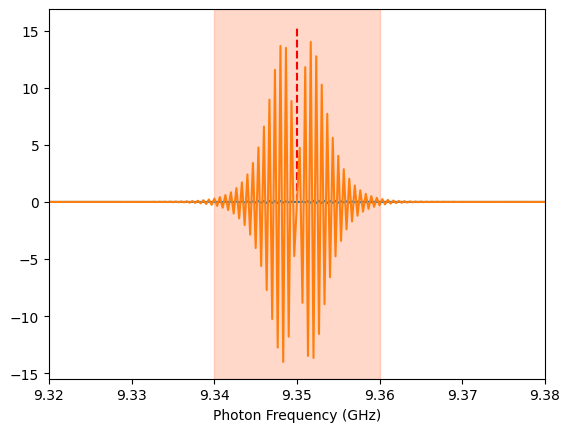

In [31]:
duration = 1000
const = 3e-3 * 2 * np.pi
readout_lo_freq = 9.35
target_freq = 9.35
passing_band = 0.01

waveform = sech_1(time, const)*np.exp(-2j*np.pi*time*(readout_lo_freq-target_freq))
plt.plot(time, waveform)
plt.show()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
# time, waveform = start_stop(time, waveform, 0, duration)
xfft, fourier = fourier_tr_padding_odd(time, waveform, 3)
# xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.32, 9.38)
ax.set_xlabel("Photon Frequency (GHz)")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, fourier.real)
ax.plot(photon_freq, fourier.imag)
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(9.32, 9.38)
ax.set_xlabel("Photon Frequency (GHz)")

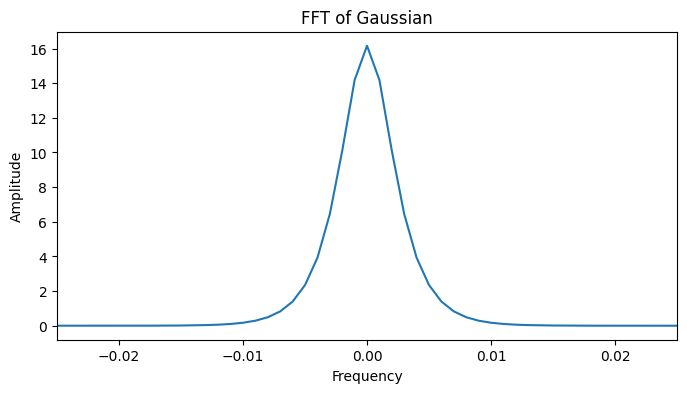

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# 時間軸 # 中心0で偶関数的

# ガウシアン波形（幅sigma=1）
sigma = 1.0
y = waveform

# FFT
N = len(y)
dt = time[1] - time[0]
y_fft = np.fft.fft(y)
freq = np.fft.fftfreq(N, dt)

# FFTをゼロ中心にシフト
y_fft_shifted = np.fft.fftshift(y_fft)
freq_shifted = np.fft.fftshift(freq)

# プロット
plt.figure(figsize=(8,4))
plt.plot(freq_shifted, np.abs(y_fft_shifted))
plt.xlim(-0.025, 0.025)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.title("FFT of Gaussian")
plt.show()


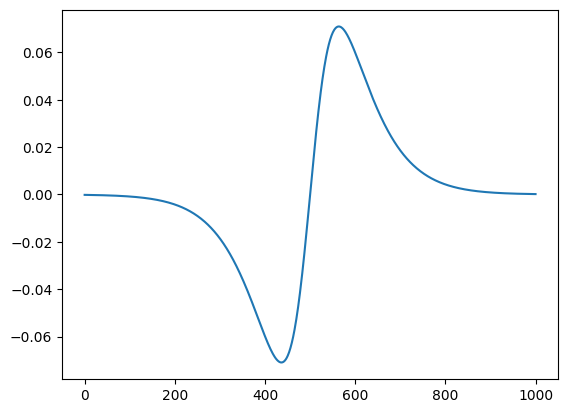

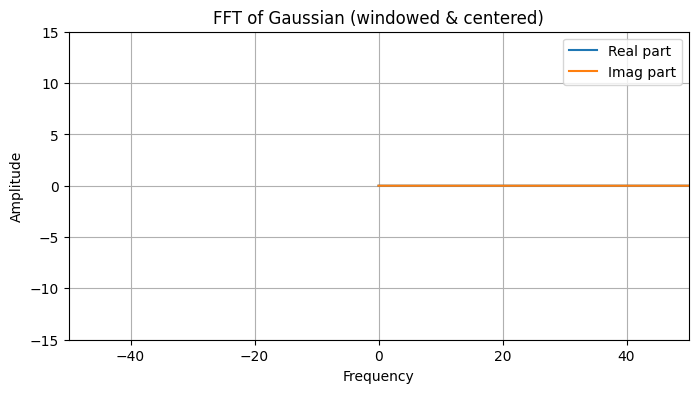

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
sigma = 0.1
t_max = 6*sigma      # 端を十分小さくする
N = 4097             # 奇数にして中心をサンプルに載せる

# 時間軸（中心0を明示）
t = time
y = waveform
plt.plot(t, y)
plt.show()

# # --- 端の不連続を抑える窓（Tukey; alpha=0.2程度が穏当） ---
# alpha = 0.2
# n = np.arange(N)
# tukey = np.ones(N)
# edge = int(alpha*(N-1)/2)
# if edge > 0:
#     ramp = 0.5*(1+np.cos(np.pi*(2*n[:edge]/(alpha*(N-1)) - 1)))
#     tukey[:edge] = ramp
#     tukey[-edge:] = ramp[::-1]
# yw = y * tukey

# --- 中心合わせ（時間→周波数のゼロ位相に）---
# 奇数長で t=0 が中央サンプルなので、そのままでもOKだが、
# 一般形に合わせて ifftshift -> FFT -> fftshift の流儀で。
yw_cent = np.fft.ifftshift(y)  # 中央サンプルがインデックス0側へ

# FFT
Y = np.fft.fft(yw_cent)
Y = np.fft.fftshift(Y)
f = np.fft.fftfreq(N, d=(t[1]-t[0]))
f = np.fft.fftshift(f)

# プロット
plt.figure(figsize=(8,4))
plt.plot(f, Y.real, label='Real part')
plt.plot(f, Y.imag, label='Imag part')
plt.xlim(-50, 50)  # 必要なら周波数範囲を調整
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.title('FFT of Gaussian (windowed & centered)')
plt.legend(); plt.grid(True); plt.show()


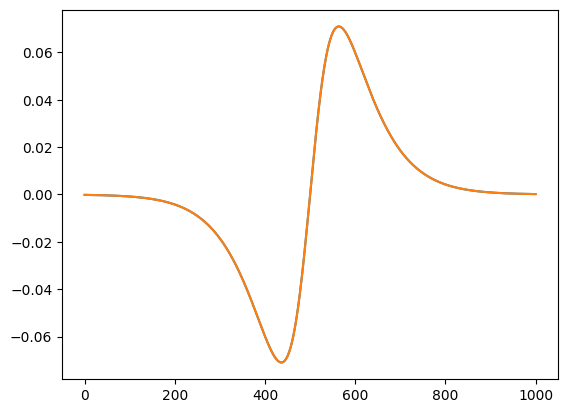

In [8]:
waveform = sech_1(time, const)
phase = np.angle(waveform)
plt.plot(time, waveform)
plt.plot(time, np.abs(waveform)*np.exp(-1j*phase))

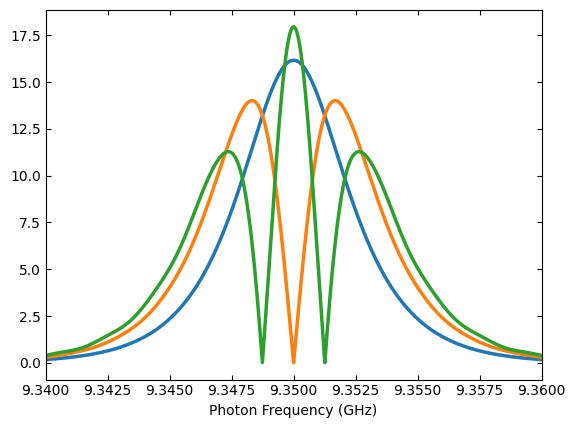

In [6]:
import numpy as np
import matplotlib.pyplot as plt

waveforms = {
    "sech0": sech_0(time, const),
    "sech1": sech_1(time, const),
    "sech2": sech_2(time, const),
    # "sech3": sech_3(time, const),
}

fig, ax = plt.subplots()

for label, waveform in waveforms.items():
    waveform = waveform * np.exp(-2j * np.pi * time * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.plot(photon_freq, np.abs(fourier), label=label, linewidth=2.5)

# ax.vlines(target_freq, 0, max(np.abs(fourier)) * 1.1, color="r", ls="--", label="Target Frequency")
# ax.axvspan(target_freq - passing_band, target_freq + passing_band, color="coral", alpha=0.3)
plt.tick_params(axis="x", direction="in")
plt.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
ax.set_xlim(9.34, 9.36)
ax.set_xlabel("Photon Frequency (GHz)")
# ax.legend)
plt.savefig("freq")
plt.show()


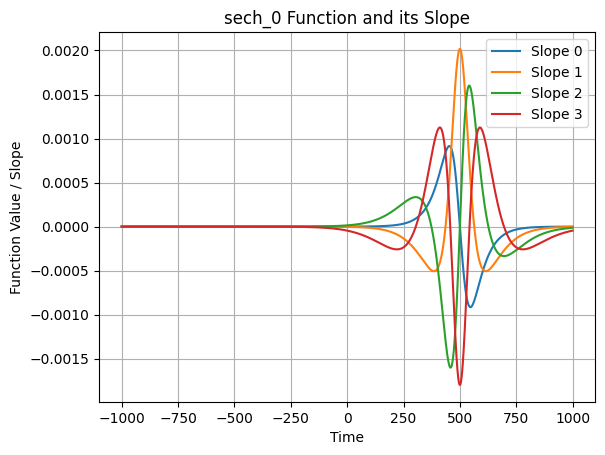

d(xi_0)/dt <  0.000914969489063111
d(xi_1)/dt <  0.0020177876798349766
d(xi_2)/dt <  0.0016016524044537572
d(xi_3)/dt <  0.0017979570455617204


In [7]:
def derivative(f, x, const, dx=1e-8):
    return (f(x + dx, const) - f(x - dx, const)) / (2 * dx)

time_vals = np.linspace(-1000, 1000, 5000) 

slope_vals_0 = [derivative(sech_0, t, const) for t in time_vals]
slope_vals_1 = [derivative(sech_1, t, const) for t in time_vals]
slope_vals_2 = [derivative(sech_2, t, const) for t in time_vals]
slope_vals_3 = [derivative(sech_3, t, const) for t in time_vals]


# plt.plot(time_vals, sech_vals, label="sech_0(t)")  
plt.plot(time_vals, slope_vals_0, label="Slope 0") 
plt.plot(time_vals, slope_vals_1, label="Slope 1") 
plt.plot(time_vals, slope_vals_2, label="Slope 2") 
plt.plot(time_vals, slope_vals_3, label="Slope 3") 
plt.xlabel("Time")
plt.ylabel("Function Value / Slope")
plt.title("sech_0 Function and its Slope")
plt.legend()
plt.grid(True)
plt.show()
print("d(xi_0)/dt < ", np.max(np.abs(slope_vals_0)))
print("d(xi_1)/dt < ", np.max(np.abs(slope_vals_1)))
print("d(xi_2)/dt < ", np.max(np.abs(slope_vals_2)))
print("d(xi_3)/dt < ", np.max(np.abs(slope_vals_3)))

In [8]:
(const/2)**1.5

0.0009149696554356844

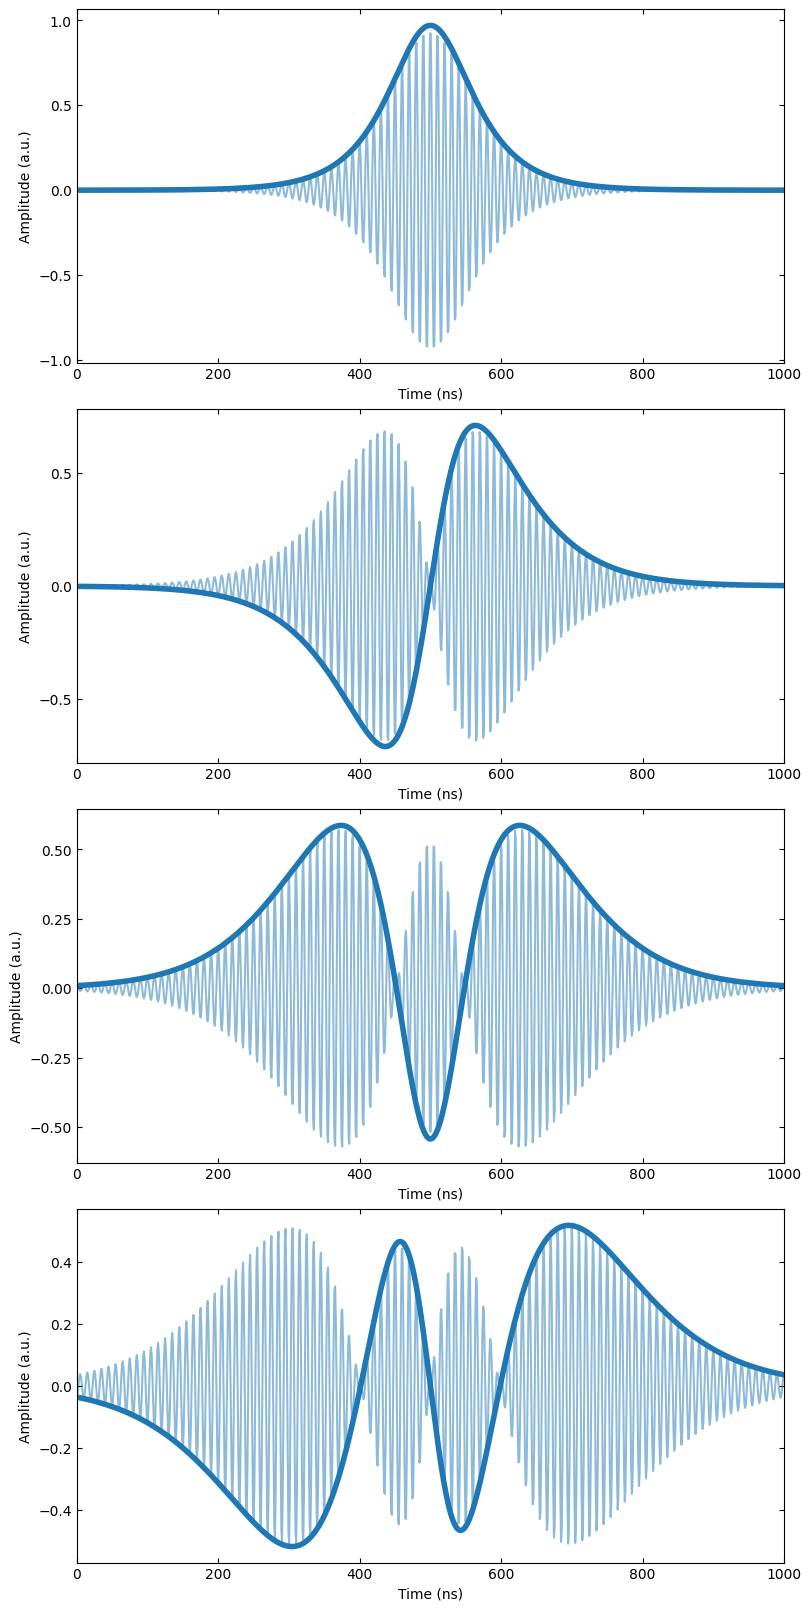

In [9]:
fig, ax = plt.subplots(4,1,figsize=(8,16),constrained_layout=True)
plt.rcParams["font.size"] = 20

ax[0].set_xlabel(r"Time (ns)")
ax[0].set_ylabel("Amplitude (a.u.)")
ax[0].set_xlim(0, 1000)
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].tick_params(top='on',bottom='on',left='on',right='on',)
ax[1].set_xlabel(r"Time (ns)")
ax[1].set_ylabel("Amplitude (a.u.)")
ax[1].set_xlim(0, 1000)
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].tick_params(top='on',bottom='on',left='on',right='on',)
ax[2].set_xlabel(r"Time (ns)")
ax[2].set_ylabel("Amplitude (a.u.)")
ax[2].set_xlim(0, 1000)
ax[2].tick_params(axis="x", direction="in")
ax[2].tick_params(axis="y", direction="in")
ax[2].tick_params(top='on',bottom='on',left='on',right='on',)
ax[3].set_xlabel(r"Time (ns)")
ax[3].set_ylabel("Amplitude (a.u.)")
ax[3].set_xlim(0, 1000)
ax[3].tick_params(axis="x", direction="in")
ax[3].tick_params(axis="y", direction="in")
ax[3].tick_params(top='on',bottom='on',left='on',right='on',)

ph_if = 100e6
ax[0].plot(time, 10*sech_0(time, const)*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_0(t)$", color="tab:blue", alpha=0.5)
ax[1].plot(time, 10*sech_1(time, const)*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_1(t)$", color="tab:blue", alpha=0.5)
ax[2].plot(time, 10*sech_2(time, const)*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_2(t)$", color="tab:blue", alpha=0.5)
ax[3].plot(time, 10*sech_3(time, const)*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_3(t)$", color="tab:blue", alpha=0.5)

ax[0].plot(time, 10*sech_0(time, const), label=r"$\xi_0(t)$", color="tab:blue", linewidth=4)
ax[1].plot(time, 10*sech_1(time, const), label=r"$\xi_1(t)$", color="tab:blue", linewidth=4)
ax[2].plot(time, 10*sech_2(time, const), label=r"$\xi_2(t)$", color="tab:blue", linewidth=4)
ax[3].plot(time, 10*sech_3(time, const), label=r"$\xi_3(t)$", color="tab:blue", linewidth=4)

# plt.legend()

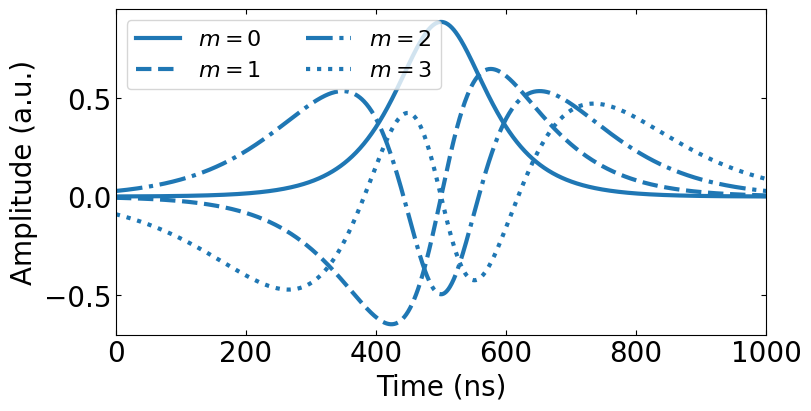

In [34]:
fig, ax = plt.subplots(1,1,figsize=(8,4),constrained_layout=True)
plt.rcParams["font.size"] = 20

ax.set_xlabel(r"Time (ns)")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_xlim(0, 1000)
ax.set_ylim(-0.7, 0.95)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.tick_params(top='on',bottom='on',left='on',right='on',)

ax.plot(time+500, 10*sech_0(time+500, const), linestyle='-', label=r"$m=0$", color="tab:blue", linewidth=3)
ax.plot(time+500, 10*sech_1(time+500, const), linestyle='--', label=r"$m=1$", color="tab:blue", linewidth=3)
ax.plot(time+500, 10*sech_2(time+500, const), linestyle='-.', label=r"$m=2$", color="tab:blue", linewidth=3)
ax.plot(time+500, 10*sech_3(time+500, const), linestyle=':', label=r"$m=3$", color="tab:blue", linewidth=3)
plt.legend(loc='upper left', ncol=2, fontsize=16)
plt.savefig("target_shape_m")

In [13]:
tau = np.linspace(-100, 100, 201)
def calc_y(func, taus):
    ys = []
    for t in taus:
        def new_func(time):
            return func(time=time, tau = t)
        y = quad(new_func, time[0], time[-1])[0]**2
        ys.append(y)
    return np.array(ys)

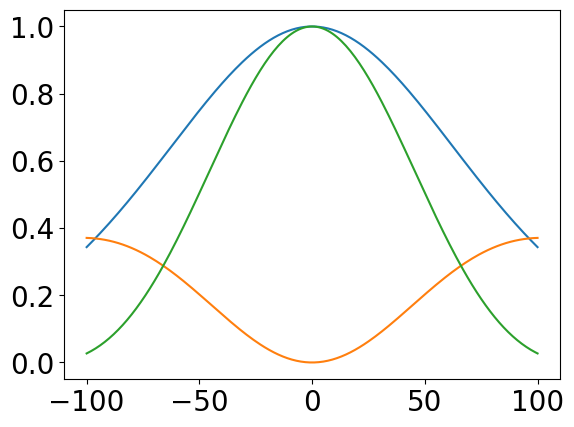

In [14]:
def sech_00(time, tau):
    return sech_0(time, const)*sech_0(time+tau, const)

def sech_01(time, tau):
    return sech_0(time, const)*sech_1(time+tau, const)

def sech_11(time, tau):
    return sech_1(time, const)*sech_1(time+tau, const)

plt.plot(tau, calc_y(sech_00, tau))
plt.plot(tau, calc_y(sech_01, tau))
plt.plot(tau, calc_y(sech_11, tau))
# print("<sech_0(t),sech_0(t)>=", quad(sech_00, time[0], time[-1])[0])
# print("<sech_1(t),sech_1(t)>=", quad(sech_11, time[0], time[-1])[0])
# print("<sech_0(t),sech_1(t)>=", quad(sech_01, time[0], time[-1])[0])

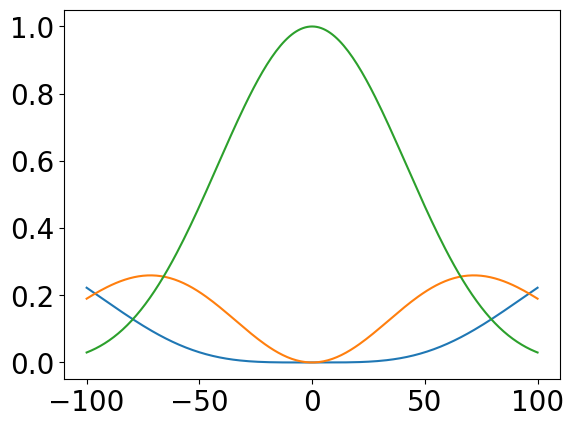

In [15]:
def sech_02(time, tau):
    return sech_0(time, const)*sech_2(time+tau, const)

def sech_12(time, tau):
    return sech_1(time, const)*sech_2(time+tau, const)

def sech_22(time, tau):
    return sech_2(time, const)*sech_2(time+tau, const)

plt.plot(tau, calc_y(sech_02, tau))
plt.plot(tau, calc_y(sech_12, tau))
plt.plot(tau, calc_y(sech_22, tau))
# print("<sech_0(t),sech_2(t)>=", quad(sech_02, time[0], time[-1])[0])
# print("<sech_1(t),sech_2(t)>=", quad(sech_12, time[0], time[-1])[0])
# print("<sech_2(t),sech_2(t)>=", quad(sech_22, time[0], time[-1])[0])

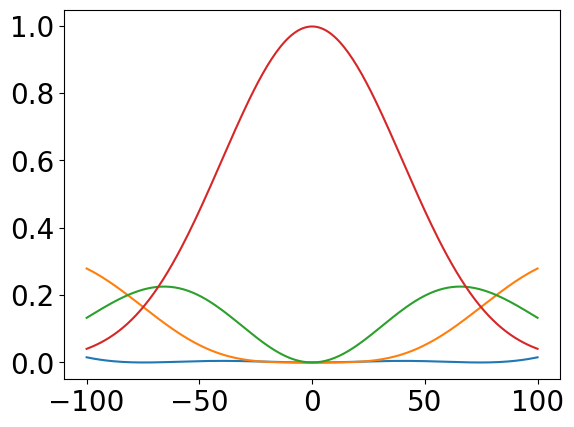

In [16]:
def sech_03(time, tau):
    return sech_0(time, const)*sech_3(time+tau, const)

def sech_13(time, tau):
    return sech_1(time, const)*sech_3(time+tau, const)

def sech_23(time, tau):
    return sech_2(time, const)*sech_3(time+tau, const)

def sech_33(time, tau):
    return sech_3(time, const)*sech_3(time+tau, const)

plt.plot(tau, calc_y(sech_03, tau))
plt.plot(tau, calc_y(sech_13, tau))
plt.plot(tau, calc_y(sech_23, tau))
plt.plot(tau, calc_y(sech_33, tau))
# print("<sech_0(t),sech_3(t)>=", quad(sech_03, time[0], time[-1])[0])
# print("<sech_1(t),sech_3(t)>=", quad(sech_13, time[0], time[-1])[0])
# print("<sech_2(t),sech_3(t)>=", quad(sech_23, time[0], time[-1])[0])
# print("<sech_3(t),sech_3(t)>=", quad(sech_33, time[0], time[-1])[0])

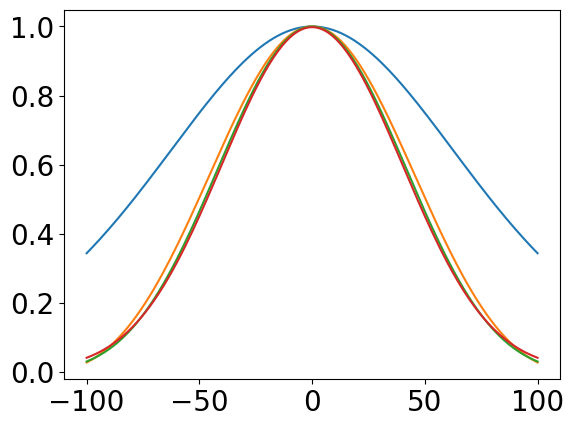

In [17]:
plt.plot(tau, calc_y(sech_00, tau))
plt.plot(tau, calc_y(sech_11, tau))
plt.plot(tau, calc_y(sech_22, tau))
plt.plot(tau, calc_y(sech_33, tau))

In [16]:
from mpmath import *

C:\Users\qipe\AppData\Local\Temp\ipykernel_14256\2888805150.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


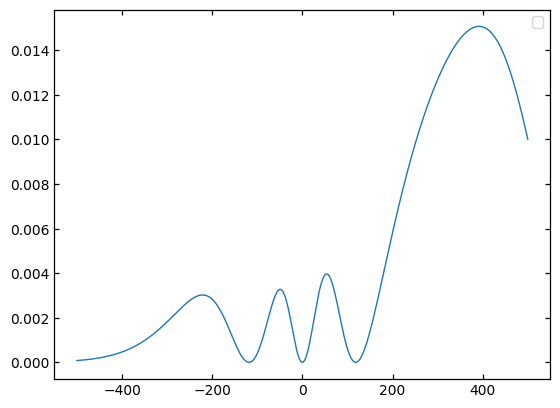

In [17]:
center = (time[0] + time[-1]) / 2
def Li_2(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_3(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_4(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_5(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_6(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
    return vectorized_polylog(values)

top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
def f(t):
    f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
    f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
    f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
    return 350*(f_3 + f_2 + f_1)/9/np.pi**6
bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))

plt.plot(time, top/bottom,)
plt.legend()
plt.show()


In [18]:
def gamma_t(time, const, plot=0, form="sech",):
        center = (time[0] + time[-1]) / 2
        def Li_2(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_3(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_4(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_5(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_6(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        if form=="sech_0":
            top = (const/2)/(np.cosh(const*(time-center)))**2
            bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
        elif form=="sech_1":                                                      
            top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
            def f(t):
                return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
            bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
        elif form=="sech_2":                                                    
            top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
                f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
                f_0 = np.pi**4*np.tanh(t)/144
                return 45*(f_2 + f_1 + f_0)/2/np.pi**4
            bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
        elif form=="sech_3":
            top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
                f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
                f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
                return 350*(f_3 + f_2 + f_1)/9/np.pi**6
            bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
        if plot:
            plt.figure(figsize=(6,2))
            plt.plot(time, top/bottom/2/np.pi)
            plt.xlabel("Time")
            plt.ylabel("Amplitude")
            plt.show()
        return top/bottom/2/np.pi

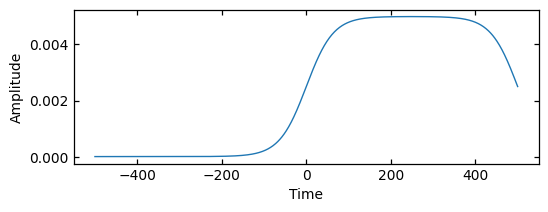

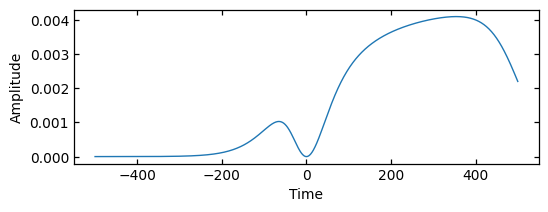

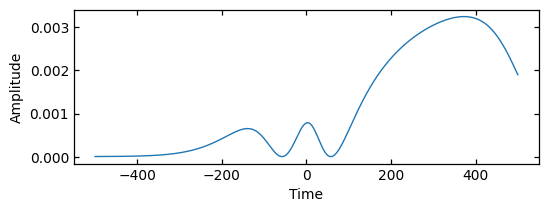

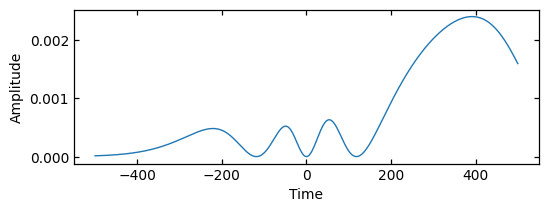

(array([7.53508411e-10, 7.77580790e-10, 8.02422212e-10, 8.28057244e-10,
        8.54511239e-10, 8.81810362e-10, 9.09981612e-10, 9.39052849e-10,
        9.69052828e-10, 1.00001122e-09, 1.03195864e-09, 1.06492668e-09,
        1.09894796e-09, 1.13405611e-09, 1.17028587e-09, 1.20767306e-09,
        1.24625466e-09, 1.28606884e-09, 1.32715495e-09, 1.36955365e-09,
        1.41330686e-09, 1.45845785e-09, 1.50505129e-09, 1.55313325e-09,
        1.60275128e-09, 1.65395447e-09, 1.70679345e-09, 1.76132047e-09,
        1.81758947e-09, 1.87565610e-09, 1.93557779e-09, 1.99741380e-09,
        2.06122529e-09, 2.12707536e-09, 2.19502915e-09, 2.26515386e-09,
        2.33751885e-09, 2.41219568e-09, 2.48925822e-09, 2.56878268e-09,
        2.65084771e-09, 2.73553447e-09, 2.82292672e-09, 2.91311090e-09,
        3.00617619e-09, 3.10221464e-09, 3.20132124e-09, 3.30359399e-09,
        3.40913406e-09, 3.51804582e-09, 3.63043698e-09, 3.74641871e-09,
        3.86610570e-09, 3.98961634e-09, 4.11707278e-09, 4.248601

In [19]:
time = np.linspace(-500, 500, 1000)
const = 2.5e-3 * 2 * np.pi
gamma_t(time, const, plot=1, form="sech_0",), gamma_t(time, const, plot=1, form="sech_1",), gamma_t(time, const, plot=1, form="sech_2",), gamma_t(time, const, plot=1, form="sech_3",)

In [20]:
import itertools
y_1 = gamma_t(time, const, plot=0, form="sech_1",)
for i in range(int(len(y_1)/2), len(y_1)):
    y_1[i] = -y_1[i]

y_2 = gamma_t(time, const, plot=0, form="sech_2",)
for i in range(442, 557): #itertools.chain(range(0, 442), range(557, len(y_2))):
        y_2[i] = -y_2[i]

y_3 = gamma_t(time, const, plot=0, form="sech_3",)
for i in itertools.chain(range(381, 500), range(618, len(y_3))):
        y_3[i] = -y_3[i]

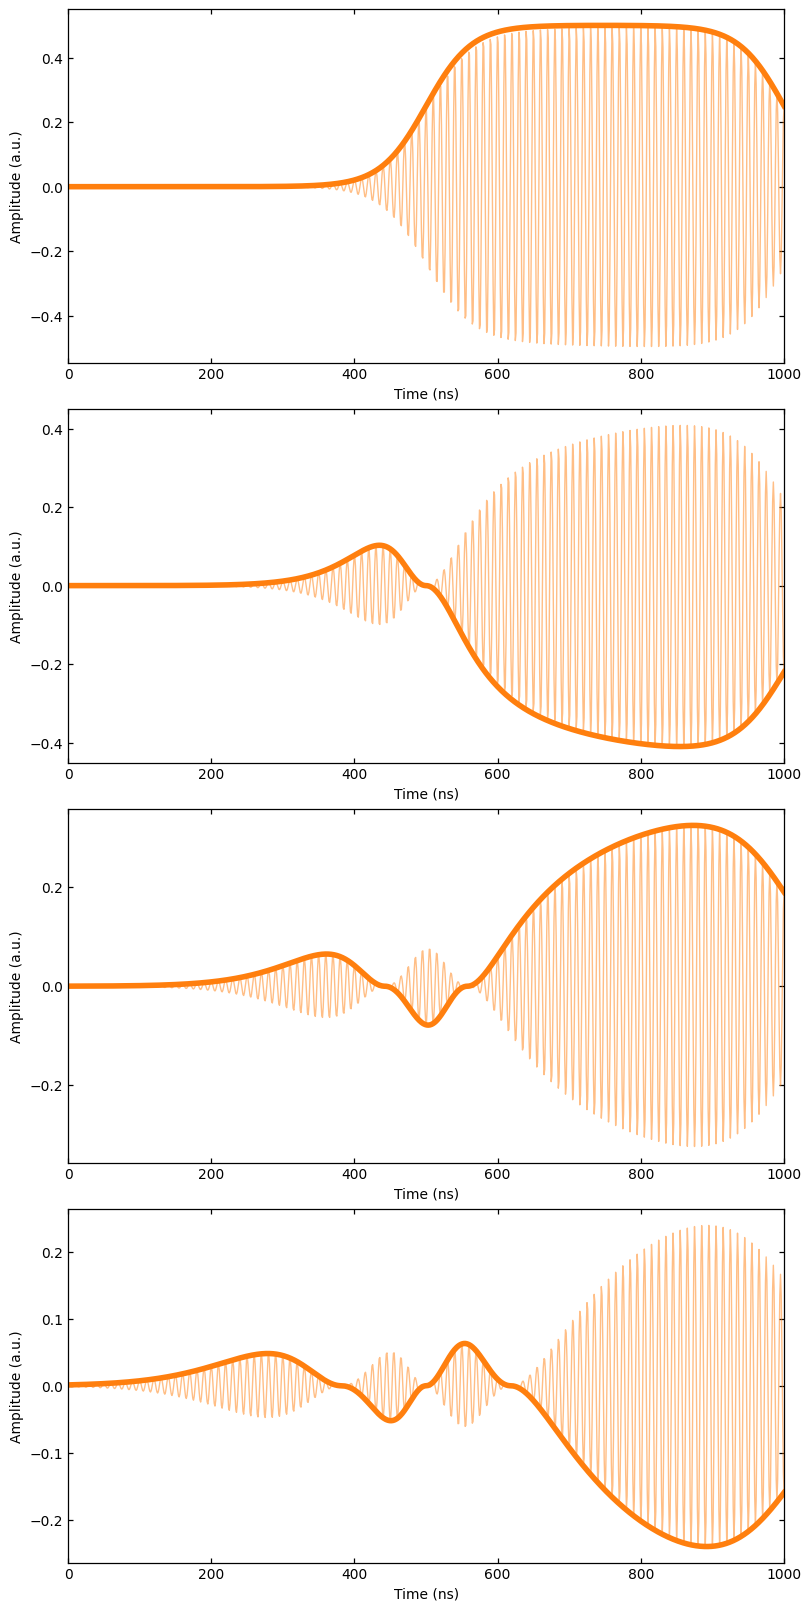

In [21]:
fig, ax = plt.subplots(4,1,figsize=(8,16),constrained_layout=True)
plt.rcParams["font.size"] = 20

ax[0].set_xlabel(r"Time (ns)")
ax[0].set_ylabel("Amplitude (a.u.)")
ax[0].set_xlim(0, 1000)
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].tick_params(top='on',bottom='on',left='on',right='on',)
ax[1].set_xlabel(r"Time (ns)")
ax[1].set_ylabel("Amplitude (a.u.)")
ax[1].set_xlim(0, 1000)
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].tick_params(top='on',bottom='on',left='on',right='on',)
ax[2].set_xlabel(r"Time (ns)")
ax[2].set_ylabel("Amplitude (a.u.)")
ax[2].set_xlim(0, 1000)
ax[2].tick_params(axis="x", direction="in")
ax[2].tick_params(axis="y", direction="in")
ax[2].tick_params(top='on',bottom='on',left='on',right='on',)
ax[3].set_xlabel(r"Time (ns)")
ax[3].set_ylabel("Amplitude (a.u.)")
ax[3].set_xlim(0, 1000)
ax[3].tick_params(axis="x", direction="in")
ax[3].tick_params(axis="y", direction="in")
ax[3].tick_params(top='on',bottom='on',left='on',right='on',)

ph_if = 100e6
ax[0].plot(time+500, 100*gamma_t(time, const, plot=0, form="sech_0",)*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_0(t)$", color="tab:orange", alpha=0.5)
ax[1].plot(time+500, 100*y_1*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_1(t)$", color="tab:orange", alpha=0.5)
ax[2].plot(time+500, 100*y_2*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_2(t)$", color="tab:orange", alpha=0.5)
ax[3].plot(time+500, 100*y_3*np.cos(2*np.pi* ph_if*time*1e-9), label=r"$\Gamma_3(t)$", color="tab:orange", alpha=0.5)

ax[0].plot(time+500,100* gamma_t(time, const, plot=0, form="sech_0",), label=r"$\Gamma_0(t)$", color="tab:orange", linewidth=4)
ax[1].plot(time+500,100* y_1, label=r"$\Gamma_1(t)$", color="tab:orange", linewidth=4)
ax[2].plot(time+500, 100*y_2, label=r"$\Gamma_2(t)$", color="tab:orange", linewidth=4)
ax[3].plot(time+500, 100*y_3, label=r"$\Gamma_3(t)$", color="tab:orange", linewidth=4)

# plt.legend()
# plt.savefig('fogi.png', bbox_inches='tight')

Text(-1.3885555555555573, 0.5, 'Amplitude (arb. unit)')

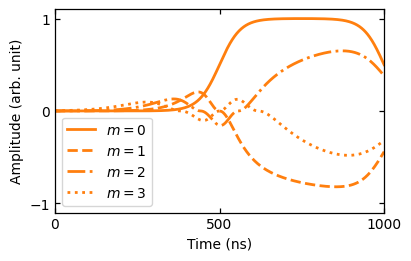

In [24]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5),constrained_layout=True)

plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 10 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True 
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

norm = np.max(gamma_t(time, const, plot=0, form="sech_0",))
ax.plot(time+500, gamma_t(time, const, plot=0, form="sech_0",)/norm, linestyle='-', label=r"$m=0$", color="tab:orange", linewidth=2)
ax.plot(time+500, y_1/norm, linestyle='--', label=r"$m=1$", color="tab:orange", linewidth=2)
ax.plot(time+500, y_2/norm, linestyle='-.', label=r"$m=2$", color="tab:orange", linewidth=2)
ax.plot(time+500, y_3/norm, linestyle=':', label=r"$m=3$", color="tab:orange", linewidth=2)
# plt.axis('off')  # 軸を非表示に
# plt.gca().set_facecolor('white')  # 背景を白に（背景が透明にされる）
ax.set_xticks([0, 500, 1000])
ax.set_yticks([-1, 0, 1])
plt.legend(loc='lower left', ncol=1)
plt.savefig("target_shape_m")
plt.xlabel("Time (ns)")
plt.ylim(-1.1, 1.1)
plt.xlim(0, 1000)
plt.ylabel("Amplitude (arb. unit)")


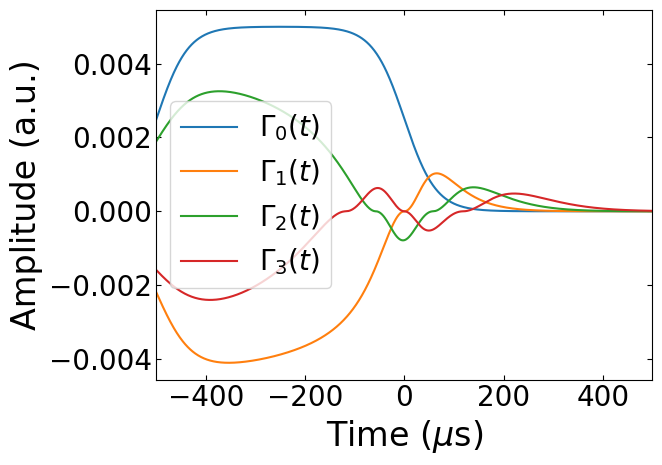

In [24]:
plt.plot(time, gamma_t(time, const, plot=0, form="sech_0",)[::-1], label=r"$\Gamma_0(t)$")
plt.plot(time, y_1[::-1], label=r"$\Gamma_1(t)$")
plt.plot(time, y_2[::-1], label=r"$\Gamma_2(t)$")
plt.plot(time, y_3[::-1], label=r"$\Gamma_3(t)$")
plt.xlabel(r"Time ($\mu$s)", size='large')
plt.ylabel("Amplitude (a.u.)", size='large')
plt.xlim(-500, 500)
# plt.ylim(-0.08, 0.1)
plt.tick_params(axis="x", direction="in")
plt.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.legend()

In [25]:
def polynomial_even(x, a0, a2, a4, a6, a8, a10):
    return a0 + a2*x**2 + a4*x**4 + a6*x**6 + a8*x**8 + a10*x**10
def guess_params_plev():
    par_ini = {'a0': 0, 'a2': 0, 'a4': 0, 'a6': 0, 'a8': 0, 'a10':0}
    par_max = {'a0': 1,'a2': np.inf,'a4': np.inf,'a6': np.inf,'a8': np.inf,'a10': np.inf,}
    par_min = {'a0': 0,'a8': 0,'a2': 0,'a10': 0,'a4': 0,'a6': 0,}
    par_vary = {'a0': 0, 'a2': 1, 'a4': 1, 'a6': 1, 'a8': 1, 'a10':1,}
    return par_ini,par_max,par_min,par_vary
def polynomial_even_fit(data, x,):
    model = lmf.Model(polynomial_even)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_plev()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, x=x, params=params, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    print(result.params.valuesdict())
    return result

In [26]:
def generate_control_pulse(self, fogi_lo, target_freq, duration, const, form="sech", plot=True, tr=True):
        time = np.arange(duration)
        Gammas = [0]
        fogi_freq_shifted = []
        amps = list(self.amps_dict.values())
        amps.insert(0, 0)
        for k, v in self.results_dict.items():
            photon_freqs = v["photon_freqs"]
            fogi_freqs = v["fogi_freqs"]
            decay_rates = v["decay_rates"]
            photonfreq_to_decayrate = interpolate.interp1d(photon_freqs, decay_rates, bounds_error=False, fill_value=(decay_rates[-1], decay_rates[0]))
            Gammas.append(photonfreq_to_decayrate(target_freq))
            photonfreq_to_fogifreq = interpolate.interp1d(photon_freqs, fogi_freqs, bounds_error=False, fill_value=(fogi_freqs[-1], fogi_freqs[0]))
            fogi_freq_shifted.append(photonfreq_to_fogifreq(target_freq))
        # envelope
        fogi_freq_shifted.insert(0, fogi_freq_shifted[0])
        # print(Gammas, amps)
        res = polynomial_even_fit(x=amps, data=Gammas)
        c = tuple(res.params.valuesdict().values())
        x = np.linspace(0, amps[-1], 10001)
        Gamma_to_amp = interpolate.interp1d(polynomial_even(x, c[0], c[1], c[2], c[3], c[4], c[5]),
                                             x, bounds_error=False, fill_value=(0, amps[-1]))
        AWGamp_of_time = lambda time:Gamma_to_amp(self.gamma_t(time, const=const, form=form))

        if tr:                                              ####### changed by Sunada
            envelope = AWGamp_of_time(time)[::-1]
        else:
            envelope = AWGamp_of_time(time)

        if plot:
            fig = plt.figure(figsize = (6.5, 3))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, res.best_fit * 1e3, )
            ax.plot(amps, np.array(Gammas)*1e3,'ro')
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{f}}$ (MHz)')
            virtual_Gamma = np.linspace(0, 20e-3, 10001)
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(virtual_Gamma, Gamma_to_amp(virtual_Gamma),'r-', label='fit')
            ax2.plot(Gammas, amps, 'ko')
            ax2.set_ylabel('Drive amplitude (V)')
            ax2.set_xlabel('$\Gamma_{\mathrm{f}}$ (GHz)')
            plt.show()

            fig = plt.figure(figsize = (6.5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax2 = fig.add_subplot(1, 2, 2)
            ax.plot(time, envelope)
            ax.set_title('AWGamplitude vs time')
            ax2.plot(time, 1/np.cosh(const * (time - duration/2)))
            # print(time, const, duration)
            ax2.set_title('target shape')
            plt.show()

        # fogi frequency
        fogi_freq_of_AWGamp = interpolate.interp1d(amps, fogi_freq_shifted, bounds_error=False, 
                                                   fill_value=(fogi_freq_shifted[0], fogi_freq_shifted[-1]))
        
        def fogi_freq_of_time(time):
            if tr:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time)[::-1])
            else:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time))
            return f_freq
        fogi_frequency = fogi_freq_of_time(time) 
        
        if plot:
            fig = plt.figure(figsize=(5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, fogi_freq_of_AWGamp(amps), "ro", ls="--")
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{ph}}$')
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(time, fogi_frequency) 
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Momentary frequency')
            plt.show()

        # generation
        phase_of_time=[0]
        for i in range(1,len(time)):
            next_phi = phase_of_time[i-1]+(fogi_frequency[i] - fogi_lo) 
            phase_of_time.append(next_phi)
        phase_of_time = np.array(phase_of_time)
        if form == "anti_sech":                                 ### changed by Sunada
            for i in range(int(len(time)/2), len(time)):
                envelope[i] = -envelope[i]
        waveform_at_AWG = envelope*np.exp(2j * np.pi * phase_of_time) 
        if plot:
            plt.figure(figsize=(4, 3))
            plt.plot(time,waveform_at_AWG.real)
            plt.plot(time,waveform_at_AWG.imag)
            plt.plot(time,envelope)
            plt.show()
        return waveform_at_AWG